In [1]:
library(dplyr)
library(readr)
library(ggplot2)

dir.create("../../outputs/Extended", recursive = TRUE, showWarnings = FALSE)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




# Methylation Analyses

In [2]:
dir <- "../../data/Extended/Methylation/"
cell_types <- c("Endothelium","Liver-Hep","Eryth-prog","Blood-T","Blood-NK",
  "Blood-Mono+Macro","Blood-Granul","Blood-B","Lung-Ep-Bron","Lung-Ep-Alveo")

files <- list.files(dir, pattern = "_lib1_celfie-ish\\.txt$", full.names = TRUE)
sample_names <- sub("_celfie-ish\\.txt$", "", basename(files))

# ---- check for column-count mismatches before rbinding ----
col_counts <- sapply(files, function(f) ncol(read.table(f, sep = "\t")))

if (any(col_counts != length(cell_types))) {
  bad_files <- files[col_counts != length(cell_types)]
  message("Dropping ", length(bad_files), " file(s) with unexpected column count:")
  print(basename(bad_files))
  
  keep <- col_counts == length(cell_types)
  files <- files[keep]
  sample_names <- sample_names[keep]
}


In [3]:
df <- do.call(rbind, lapply(files, read.table, sep = "\t"))
colnames(df) <- cell_types
rownames(df) <- sample_names

In [4]:
meta <- read.csv("../../data/Extended/Methylation/lucas-meta-cohorts.csv", stringsAsFactors = FALSE, na.strings = "")
meta$Group <- ifelse(meta$Stage == "NA", "Healthy", meta$Stage)
meta$Group <- factor(meta$Group, levels = c("Healthy", "I", "II", "III", "IV"))

sample_patient <- sub("_5B_.*$", "", rownames(df))

df2 <- df
df2$Patient <- sample_patient
df2 <- merge(df2, meta[, c("Patient", "Group")], by = "Patient")

In [5]:
lucas_df_with_pcs <- read_csv("../../data/lucas_df_with_pcs.csv")

pc_cols <- grep("^ratio_pc_", colnames(lucas_df_with_pcs), value = TRUE)

# keep Patient + PC scores + Stage from the new df
pcs <- lucas_df_with_pcs[, c("Patient", "Stage", pc_cols)]

# merge onto df2 (already has Patient, Group, and all cell-type columns)
df3 <- merge(df2, pcs, by = "Patient")

Rows: 287 Columns: 958
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr   (96): Patient, id, type, clinical_smokingstatus, QC, patient.type, cli...
dbl  (850): multinucratio, clinical_nlratio, clinical_CRP, clinical_cfdna_co...
lgl    (3): DIAGNOSE_OTHER_PRIMARY, Adaptor Dimer, Date Data Received
date   (9): DATE_1_VISIT_BBH, DATE_BIOPSY, DATE_SCAN_BASELINE, DATE_FEV1, DA...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [6]:
df3_filtered <- subset(df3, select = c(Endothelium, `Liver-Hep`, `Eryth-prog`, `Blood-T`, `Blood-NK`, 
                                       `Blood-Mono+Macro`, `Blood-Granul`, `Blood-B`, `Lung-Ep-Bron`, `Lung-Ep-Alveo`))


In [7]:
summary_df <- data.frame(
  mean   = sapply(df3_filtered, mean),
  median = sapply(df3_filtered, median)
)

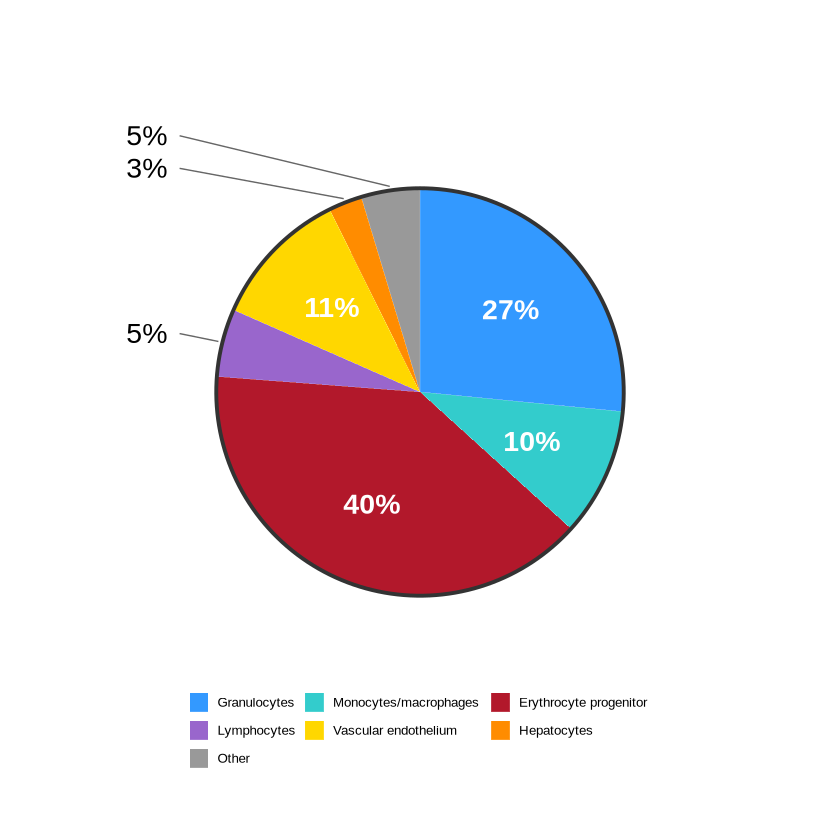

In [8]:
library(ggplot2)
library(dplyr)

# ---- aggregate your 31 cell types into the paper's categories ----
pie_df <- data.frame(
  category = c("Granulocytes", "Monocytes/macrophages", "Erythrocyte progenitor",
               "Lymphocytes", "Vascular endothelium", "Hepatocytes", "Other"),
  value = c(
    summary_df["Blood-Granul", "mean"],
    summary_df["Blood-Mono+Macro", "mean"],
    summary_df["Eryth-prog", "mean"],
    summary_df["Blood-T", "mean"] + summary_df["Blood-NK", "mean"] + summary_df["Blood-B", "mean"],
    summary_df["Endothelium", "mean"],
    summary_df["Liver-Hep", "mean"],
    NA
  )
)
pie_df$value[7] <- 100 - sum(pie_df$value[1:6])

colors <- c("Granulocytes" = "#3399FF", "Monocytes/macrophages" = "#33CCCC",
            "Erythrocyte progenitor" = "#B2182B", "Lymphocytes" = "#9966CC",
            "Vascular endothelium" = "#FFD700", "Hepatocytes" = "#FF8C00",
            "Other" = "#999999")

pie_df$category <- factor(pie_df$category, levels = pie_df$category)
pie_df$label <- paste0(round(pie_df$value), "%")

# ---- cumulative angles (clockwise from 12 o'clock) ----
pie_df <- pie_df %>%
  arrange(category) %>%
  mutate(
    fraction    = value / sum(value),
    end_frac    = cumsum(fraction),
    start_frac  = c(0, head(end_frac, -1)),
    start_angle = start_frac * 2 * pi,
    end_angle   = end_frac   * 2 * pi,
    mid_angle   = (start_angle + end_angle) / 2,
    is_small    = fraction < 0.06
  )

# ---- wedge polygons ----
make_wedge <- function(cat, start_angle, end_angle, r = 1, n = 100) {
  angles <- seq(start_angle, end_angle, length.out = n)
  data.frame(
    category = cat,
    x = c(0, r * sin(angles), 0),
    y = c(0, r * cos(angles), 0)
  )
}
wedges <- do.call(rbind, lapply(seq_len(nrow(pie_df)), function(i) {
  make_wedge(pie_df$category[i], pie_df$start_angle[i], pie_df$end_angle[i])
}))
wedges$category <- factor(wedges$category, levels = levels(pie_df$category))

# ---- outer rim circle (drawn separately for a thicker, distinct border) ----
rim <- data.frame(
  x = sin(seq(0, 2 * pi, length.out = 200)),
  y = cos(seq(0, 2 * pi, length.out = 200))
)

# ---- label positions ----
label_df <- pie_df %>%
  mutate(
    r_label = ifelse(is_small, 1.18, 0.6),
    lx  = r_label * sin(mid_angle),
    ly  = r_label * cos(mid_angle),
    lx0 = 1.02 * sin(mid_angle),
    ly0 = 1.02 * cos(mid_angle),
    side = ifelse(sin(mid_angle) >= 0, "right", "left")
  )

# ---- declutter small-wedge labels vertically ----
declutter <- function(df, min_gap = 0.16) {
  if (nrow(df) <= 1) return(df)
  df <- df[order(df$ly), ]
  for (i in seq_len(nrow(df))[-1]) {
    if (df$ly[i] - df$ly[i - 1] < min_gap) {
      df$ly[i] <- df$ly[i - 1] + min_gap
    }
  }
  df
}
small_right <- declutter(subset(label_df, is_small & side == "right"))
small_left  <- declutter(subset(label_df, is_small & side == "left"))
label_df <- rbind(subset(label_df, !is_small), small_right, small_left)

label_df <- label_df %>%
  mutate(
    lx1 = ifelse(is_small, ifelse(side == "right", 1.18, -1.18), lx),
    ly1 = ly,
    label_x = ifelse(is_small, ifelse(side == "right", lx1 + 0.06, lx1 - 0.06), lx),
    hjust   = ifelse(is_small, ifelse(side == "right", 0, 1), 0.5)
  )

# ---- plot ----
p <- ggplot() +
  geom_polygon(data = wedges, aes(x = x, y = y, fill = category, group = category),
               color = "white", linewidth = 0.04) +          # thin dividers between slices
  geom_path(data = rim, aes(x = x, y = y),
            color = "grey20", linewidth = 1.1) +             # thick outer rim, drawn on top
  geom_segment(data = subset(label_df, is_small),
               aes(x = lx0, y = ly0, xend = lx1, yend = ly1),
               color = "grey40", linewidth = 0.4) +
  geom_text(data = subset(label_df, !is_small),
            aes(x = lx, y = ly, label = label), size = 6, color = "white", fontface = "bold") +
  geom_text(data = subset(label_df, is_small),
            aes(x = label_x, y = ly1, label = label, hjust = hjust),
            size = 6, color = "black") +
  scale_fill_manual(values = colors, name = NULL) +
  coord_fixed(clip = "off") +
  xlim(-1.8, 1.8) +
  ylim(-1.3, 1.3) +
  labs(title = "") +
  theme_void(base_size = 11) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 12, margin = margin(b = 6)),
    legend.position = "bottom",
    legend.text = element_text(size = 8),
    legend.key.size = unit(0.4, "cm"),
    plot.margin = margin(10, 10, 10, 10)
  ) +
  guides(fill = guide_legend(nrow = 3, byrow = TRUE))

p

ggsave("../../outputs/Extended/Ext-Data-Fig-6-Methylation-Deconv-Pie-Chart.png", p, width = 8, height = 8, units = "in", dpi = 600)



In [9]:
df2 <- subset(df3, select = c(Patient, Endothelium, `Liver-Hep`, `Eryth-prog`, `Blood-T`, `Blood-NK`, 
                                       `Blood-Mono+Macro`, `Blood-Granul`, `Blood-B`, `Lung-Ep-Bron`, `Lung-Ep-Alveo`, Group))


In [10]:
cell_types <- setdiff(colnames(df2), c("Patient", "Group"))

# Healthy mean and SD per cell type (used as the reference/baseline)
healthy <- df2[df2$Group == "Healthy", cell_types]
healthy_mean <- sapply(healthy, mean, na.rm = TRUE)
healthy_sd   <- sapply(healthy, sd, na.rm = TRUE)

# Mean per cell type for each disease stage
stage_means <- aggregate(df2[cell_types], by = list(Group = df2$Group), FUN = mean, na.rm = TRUE)
rownames(stage_means) <- stage_means$Group
stage_means$Group <- NULL

In [11]:
z_mat <- sweep(stage_means[c("I", "II", "III", "IV"), ], 2, healthy_mean, "-")
z_mat <- sweep(z_mat, 2, healthy_sd, "/")

In [12]:
library(ggplot2)
library(tidyr)
library(dplyr)

# --- data prep ---
z_df <- as.data.frame(z_mat)
z_df$Group <- rownames(z_df)
z_long <- pivot_longer(z_df, -Group, names_to = "cell_type", values_to = "z")
z_long$Group <- factor(z_long$Group, levels = c("I", "II", "III", "IV"))

# order cell types by hierarchical clustering for a more informative layout
clust_order <- z_mat |>
  t() |>
  dist() |>
  hclust(method = "average")
z_long$cell_type <- factor(z_long$cell_type, levels = clust_order$labels[clust_order$order])

# cap symmetric color scale at a sensible max (avoids one outlier washing out the palette)
zmax <- max(abs(z_long$z), na.rm = TRUE)

# --- plot ---
p <- ggplot(z_long, aes(x = Group, y = cell_type, fill = z)) +
  geom_tile(color = "white", linewidth = 0.6) +
  geom_text(aes(label = sprintf("%.1f", z),
                color = abs(z) > zmax * 0.6),
            size = 3.4, show.legend = FALSE) +
  scale_color_manual(values = c("FALSE" = "black", "TRUE" = "white")) +
  scale_fill_gradient2(
    low = "#2166AC", mid = "white", high = "#B2182B",
    midpoint = 0, limits = c(-zmax, zmax),
    name = "Z-score\n(vs Healthy)"
  ) +
  scale_x_discrete(expand = c(0, 0)) +
  scale_y_discrete(expand = c(0, 0)) +
  coord_fixed() +
  labs(x = NULL, y = NULL,
       title = "") +
  theme_minimal(base_size = 11, base_family = "Helvetica") +
  theme(
    axis.text.y      = element_text(size = 10, color = "black"),
    axis.text.x      = element_text(size = 11, color = "black"),
    axis.ticks       = element_blank(),
    panel.grid       = element_blank(),
    plot.title       = element_text(hjust = 0.5, face = "bold", size = 12,
                                     margin = margin(b = 8)),
    legend.title     = element_text(size = 9, hjust = 0.5),
    legend.text      = element_text(size = 8),
    legend.key.width = unit(0.4, "cm"),
    legend.key.height= unit(0.9, "cm"),
    plot.margin      = margin(10, 10, 10, 10)
  )

Loading required package: grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


circlize version 0.4.16
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize implements a

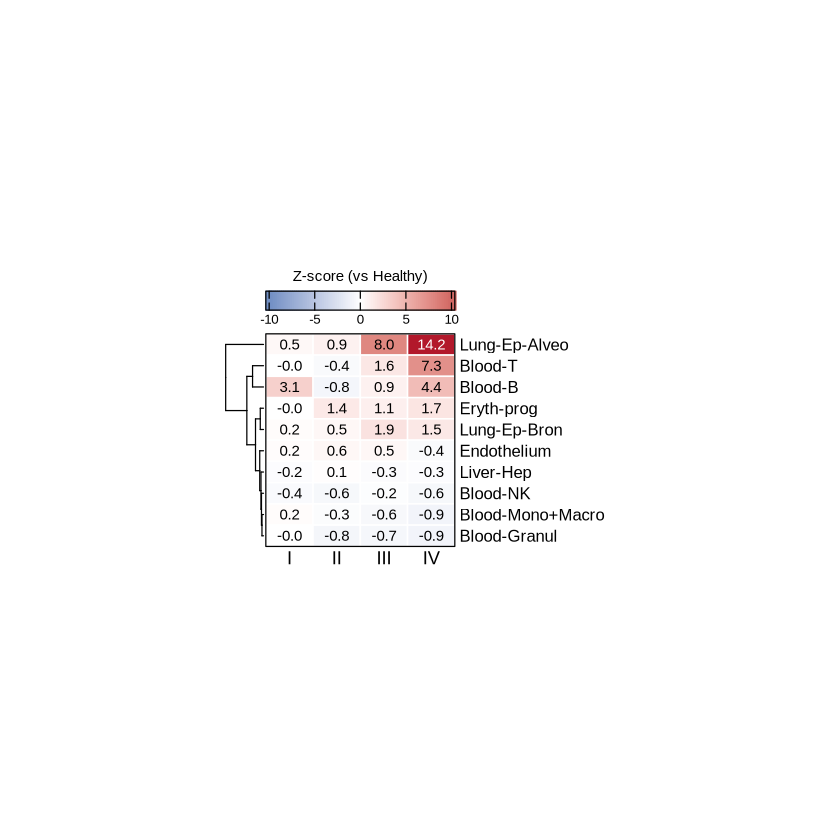

In [13]:
library(ComplexHeatmap)
library(circlize)
library(grid)

# --- data prep ---
mat <- t(as.matrix(z_mat))
mat <- mat[, c("I", "II", "III", "IV")]

# --- symmetric, outlier-aware color scale ---
zmax <- max(abs(mat), na.rm = TRUE)
col_fun <- colorRamp2(c(-zmax, 0, zmax), c("#2166AC", "white", "#B2182B"))

# --- heatmap ---
ht <- Heatmap(
  mat,
  name = "zscore",
  col = col_fun,

  cluster_rows = TRUE,
  cluster_columns = FALSE,
  clustering_distance_rows = "euclidean",
  clustering_method_rows = "average",
  show_row_dend = TRUE,
  row_dend_width = unit(8, "mm"),

  cell_fun = function(j, i, x, y, width, height, fill) {
    txt_col <- ifelse(abs(mat[i, j]) > zmax * 0.6, "white", "black")
    grid.text(sprintf("%.1f", mat[i, j]), x, y,
              gp = gpar(fontsize = 9, col = txt_col))
  },

  rect_gp = gpar(col = "white", lwd = 1.2),
  border = TRUE,

  row_names_gp = gpar(fontsize = 10),
  column_names_gp = gpar(fontsize = 11),
  column_names_rot = 0,
  column_names_centered = TRUE,
  column_title = NULL,

  width = unit(4, "cm"),
  height = unit(4.5, "cm"),

  heatmap_legend_param = list(
    title = "Z-score (vs Healthy)",
    title_position = "topcenter",
    direction = "horizontal",
    legend_width = unit(4, "cm"),
    #at = seq(-round(zmax), round(zmax), by = 1),  # <- tick positions
    at = c(-10, -5, 0, 5, 10),
    tick_length = unit(1.5, "mm"),                 # <- tick mark length
    border = "black",                              # <- legend border
    title_gp = gpar(fontsize = 9, fontface = "plain"),
    labels_gp = gpar(fontsize = 8)
  )
)

draw(ht, heatmap_legend_side = "top", padding = unit(c(2, 2, 2, 2), "mm"))


In [14]:
png("../../outputs/Extended/Ext-Data-Fig-6-Methylation-Stage-Heatmap_Zscore-subset.png", width = 5, height = 5.2, units = "in", res = 600)
draw(ht, heatmap_legend_side = "top", padding = unit(c(2, 2, 2, 2), "mm"))
dev.off()

pdf 
  2

## Fragmentome PC Analyses

In [15]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(compositions)   
library(zoo)            
library(scales)

# ---- derive cell_types and pc_cols directly from df3 ----
pc_cols <- grep("^ratio_pc_", colnames(df3), value = TRUE)
non_cell_cols <- c("Patient", "Group", "Stage", pc_cols)
cell_types <- setdiff(colnames(df3), non_cell_cols)

# ---- CLR transform (adds small pseudocount to avoid log(0)) ----
pseudo <- 0.01
comp_mat <- as.matrix(df3[, cell_types])
comp_mat[comp_mat == 0] <- pseudo
clr_mat <- clr(comp_mat)
clr_df <- as.data.frame(clr_mat)
colnames(clr_df) <- cell_types
clr_df$Patient <- df3$Patient

# ---- CLR correlation per PC x cell type (Pearson) ----
clr_cor_results <- lapply(pc_cols, function(pc) {
  x <- df3[[pc]]
  res <- lapply(cell_types, function(ct) {
    ct_test <- cor.test(x, clr_df[[ct]], method = "pearson")
    data.frame(rho = unname(ct_test$estimate), p = ct_test$p.value)
  }) %>% bind_rows()
  data.frame(pc = pc, cell_type = cell_types, res)
}) %>% bind_rows()
clr_cor_results$p_adj <- p.adjust(clr_cor_results$p, method = "BH")



Welcome to compositions, a package for compositional data analysis.
Find an intro with "? compositions"



Attaching package: ‘compositions’


The following objects are masked from ‘package:stats’:

    anova, cor, cov, dist, var


The following object is masked from ‘package:graphics’:

    segments


The following objects are masked from ‘package:base’:

    %*%, norm, scale, scale.default



Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric



Attaching package: ‘scales’


The following object is masked from ‘package:readr’:

    col_factor




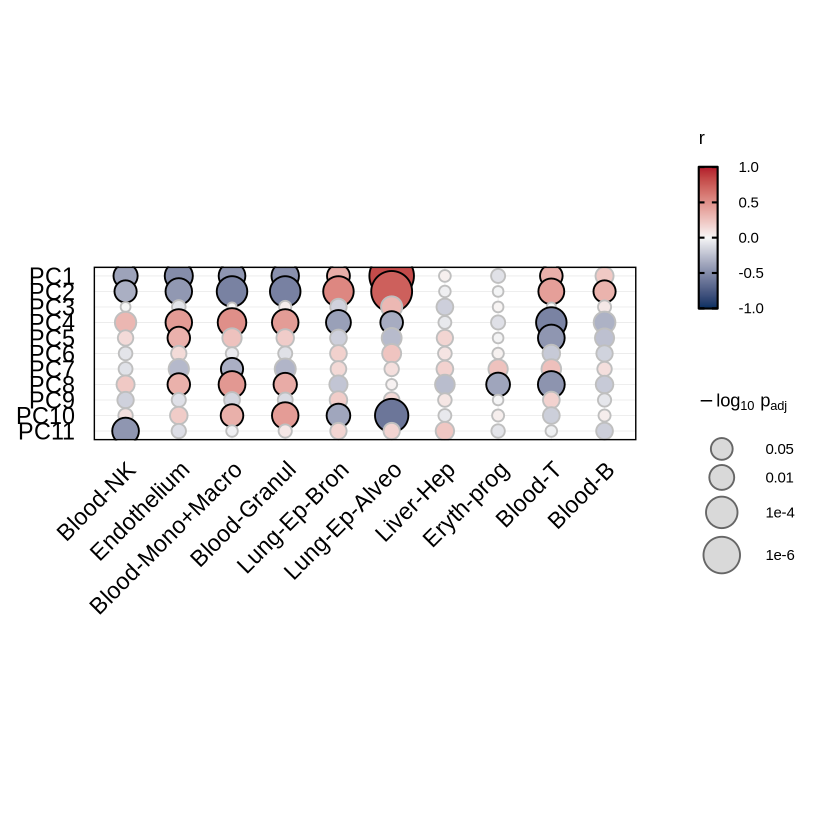

In [16]:
library(ggplot2)
library(dplyr)
library(tidyr)
library(tibble)

flip_pcs <- c(1, 2)   # PCs whose sign convention is inverted
dot_dat <- clr_cor_results %>%
  mutate(pc_num = as.integer(sub(".*_pc_?0*(\\d+)$", "\\1", pc))) %>%
  filter(pc_num %in% 1:11) %>%
  mutate(
    rho      = ifelse(pc_num %in% flip_pcs, -rho, rho),   # flip BEFORE ordering
    pc_label = factor(paste0("PC", pc_num), levels = paste0("PC", 11:1)),
    is_sig   = p_adj < 0.05,
    sig      = case_when(p_adj < 0.001 ~ "***", p_adj < 0.01 ~ "**",
                         p_adj < 0.05 ~ "*", TRUE ~ ""),
    neglogp  = pmin(-log10(pmax(p_adj, 1e-10)), 10)
  )

m <- dot_dat %>%
  select(cell_type, pc_label, rho) %>%
  pivot_wider(names_from = pc_label, values_from = rho) %>%
  column_to_rownames("cell_type") %>%
  as.matrix()
dot_dat$cell_type <- factor(dot_dat$cell_type,
                            levels = rownames(m)[hclust(dist(m))$order])

p <- ggplot(dot_dat, aes(x = cell_type, y = pc_label)) +
  geom_point(aes(size = neglogp, fill = rho, color = is_sig),
             shape = 21, stroke = 0.8) +
  scale_fill_gradient2(
    low = "#053061", mid = "#F7F7F7", high = "#B2182B", midpoint = 0,
    limits = c(-1, 1), name = "r",
    guide = guide_colorbar(frame.colour = "black", frame.linewidth = 0.6,
                           ticks.colour = "black", ticks.linewidth = 0.6,
                           barwidth = unit(0.4, "cm"), barheight = unit(3, "cm"),
                           order = 1)
  ) +
  scale_color_manual(values = c("TRUE" = "black", "FALSE" = "grey75"), guide = "none") +
  scale_size_continuous(
    range = c(2, 12), name = expression(-log[10]~p[adj]),
    breaks = c(1.3, 2, 4, 6), labels = c("0.05", "0.01", "1e-4", "1e-6"),
    guide = guide_legend(override.aes = list(fill = "grey85", color = "grey40"), order = 2)
  ) +
  scale_x_discrete(expand = expansion(add = 0.6)) +
  scale_y_discrete(expand = expansion(add = 0.6)) +
  labs(x = NULL, y = NULL,
       title = "",
       subtitle = "") +
  theme_minimal(base_size = 25, base_family = "Helvetica") +
  theme(
    aspect.ratio = 0.32,                 # <- the vertical compression knob
    plot.title = element_text(hjust = 0.5, face = "bold", size = 13, margin = margin(b = 2)),
    plot.subtitle = element_text(hjust = 0.5, size = 9, color = "grey40", margin = margin(b = 6)),
    axis.text.x = element_text(size = 14, color = "black", angle = 45, hjust = 1),
    axis.text.y = element_text(size = 14, color = "black"),
    panel.grid.major = element_line(color = "grey92", linewidth = 0.25),
    panel.grid.minor = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 0.8),
    legend.position = "right",
    legend.title = element_text(size = 11),
    legend.text = element_text(size = 9),
    legend.key.height = unit(0.4, "cm"),
    plot.margin = margin(10, 12, 8, 10)
  )
p

ggsave("../../outputs/Extended/Ext-Data-Fig-6-Methylation-PC-Dotplot.png", 
       p, width = 16, height = 16, units = "in", dpi = 600)

## Fragment Length Distributions

In [17]:
library(tidyverse)

## ---- shared settings ------------------------------------------------------
PREP   <- "../../data/Extended/"
OUTDIR <- "../../outputs/Extended/"
KEEP   <- c("Lung-Ep-Alveo", "Blood-Granul", "Blood-Mono+Macro", "Eryth-prog", "Liver-Hep")
BINW   <- 1                      # 1 bp bins; needed to resolve a 167 -> 164 shift
XLIM   <- c(75, 400)

## column order of the celfie-ish deconvolution output
celltypes <- c("Endothelium","Liver-Hep","Eryth-prog","Blood-T","Blood-NK",
               "Blood-Mono+Macro","Blood-Granul","Blood-B","Lung-Ep-Bron","Lung-Ep-Alveo")

## legend order, by short/long ratio
ct_order <- c("Blood-Granul","Blood-Mono+Macro","Endothelium","Blood-NK","Eryth-prog",
              "Liver-Hep","Blood-T","Lung-Ep-Bron","Blood-B","Lung-Ep-Alveo")

pal <- c("Blood-Granul"="#1f6fb4","Blood-Mono+Macro"="#7fb069","Endothelium"="#d1495b",
         "Blood-NK"="#2a9d5c","Eryth-prog"="#e8a33d","Liver-Hep"="#e2711d",
         "Blood-T"="#e0879a","Lung-Ep-Bron"="#5e4fa2","Blood-B"="#7fc6e8",
         "Lung-Ep-Alveo"="#a292d0")

dir.create(OUTDIR, recursive = TRUE, showWarnings = FALSE)

## Deviation of each cell type's fragment length distribution from the pooled
## distribution over the SAME fragment set and mode, so that any length
## selection imposed by a hard posterior threshold cancels rather than
## appearing as a spurious notch at 167 bp.
run_fld <- function(subset, mode, keep = KEEP, save = TRUE) {

  f <- file.path(PREP, sprintf("fld_by_celltype_%s.tsv", subset))
  if (!file.exists(f)) stop("not found: ", f)

  raw <- read_tsv(f, show_col_types = FALSE) %>%
    mutate(celltype = factor(celltypes[ct_index], levels = ct_order),
           count    = .data[[mode]],
           lbin     = floor(length / BINW) * BINW + BINW / 2) %>%
    filter(celltype %in% keep) %>%
    droplevels()

  dens <- raw %>%
    group_by(celltype, lbin) %>%
    summarise(count = sum(count), .groups = "drop_last") %>%
    mutate(dens = count / sum(count)) %>%
    ungroup()

  ## pooled reference, over the retained cell types only
  bulk <- raw %>%
    group_by(lbin) %>%
    summarise(count = sum(count), .groups = "drop") %>%
    mutate(dens_bulk = count / sum(count)) %>%
    select(lbin, dens_bulk)

  delta <- dens %>%
    left_join(bulk, by = "lbin") %>%
    mutate(d = dens - dens_bulk)

  ## short/long ratio and fragment count per cell type
  dens %>%
    group_by(celltype) %>%
    summarise(n  = round(sum(count)),
              sl = sum(count[lbin >= 100 & lbin <= 150]) /
                   sum(count[lbin >= 100 & lbin <= 250]), .groups = "drop") %>%
    print(n = Inf)

  p <- ggplot(delta, aes(lbin, d, colour = celltype)) +
    geom_hline(yintercept = 0, linewidth = 0.4, colour = "grey55") +
    geom_vline(xintercept = 167, linetype = "dashed", linewidth = 0.4, colour = "grey65") +
    geom_line(linewidth = 0.8) +
    scale_colour_manual(values = pal, name = NULL) +
    scale_x_continuous(breaks = seq(100, 400, 50)) +
    scale_y_continuous(labels = scales::label_number(scale = 1e3)) +
    coord_cartesian(xlim = XLIM) +
    labs(x = "Fragment length (bp)",
         y = expression("Density difference from pooled ("%*%10^-3*")"),
         title = sprintf("Cell-type deviation from pooled distribution (%s, %s)", subset, mode)) +
    theme_bw(base_size = 18) +
    theme(panel.grid = element_blank(),
          panel.border = element_rect(colour = "black", fill = NA, linewidth = 0.7),
          axis.text  = element_text(size = 15, colour = "black"),
          axis.title = element_text(size = 17),
          legend.text = element_text(size = 14),
          legend.key.height = unit(0.8, "cm"),
          legend.position = "right",
          plot.title = element_text(face = "bold", size = 19),
          plot.title.position = "plot")

  if (save) {
    out <- file.path(OUTDIR, sprintf("celltype_fld_deviation_%s_%s.png", subset, mode))
    ggsave(out, p, width = 11, height = 7, dpi = 600)
    cat("saved:", out, "\n")
  }
  p
}

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ purrr     1.1.0
✔ lubridate 1.9.4     ✔ stringr   1.5.1
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ scales::col_factor() masks readr::col_factor()
✖ purrr::discard()     masks scales::discard()
✖ dplyr::filter()      masks stats::filter()
✖ dplyr::lag()         masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


# A tibble: 5 × 3
  celltype              n    sl
  <fct>             <dbl> <dbl>
1 Blood-Granul     691716 0.157
2 Blood-Mono+Macro 268836 0.163
3 Eryth-prog       858171 0.163
4 Liver-Hep        117853 0.175
5 Lung-Ep-Alveo     68914 0.163
saved: ../../outputs/Extended//celltype_fld_deviation_subset_healthy_56_w_count.png 


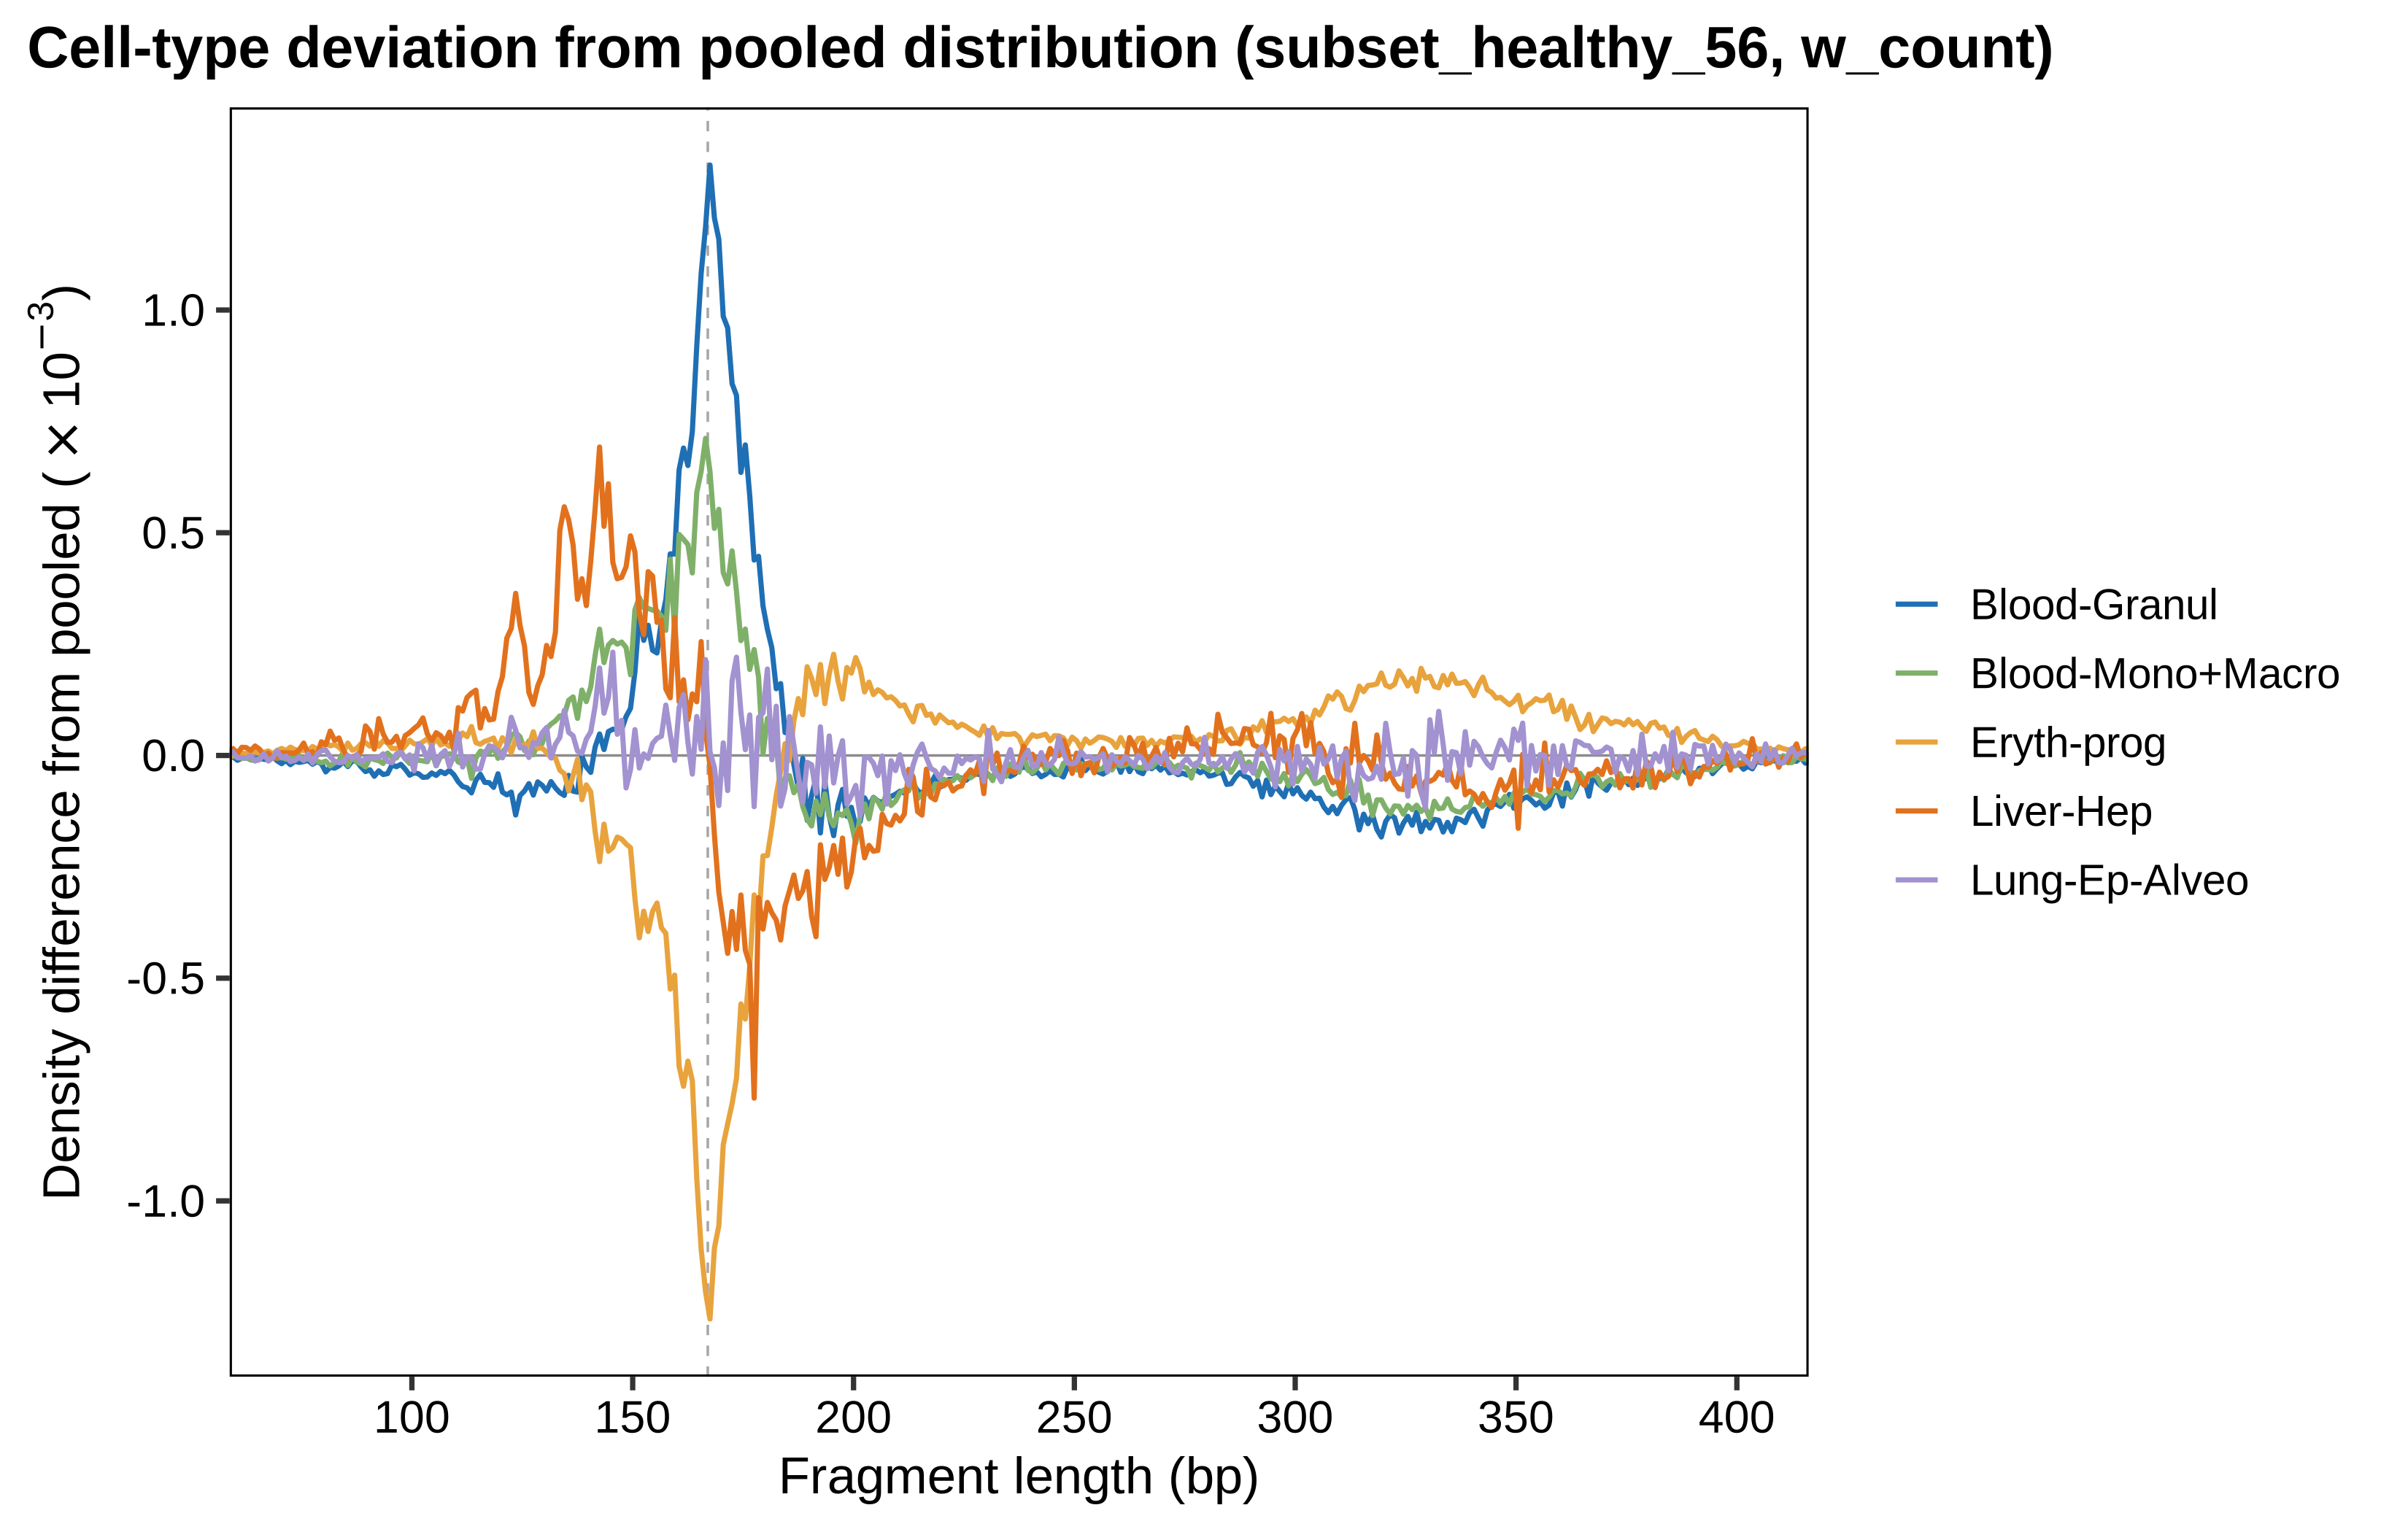

In [18]:
options(repr.plot.width = 11, repr.plot.height = 7, repr.plot.res = 300)
run_fld("subset_healthy_56", "w_count")

# A tibble: 5 × 3
  celltype               n    sl
  <fct>              <dbl> <dbl>
1 Blood-Granul      961583 0.165
2 Blood-Mono+Macro  404868 0.168
3 Eryth-prog       1464630 0.187
4 Liver-Hep         156012 0.181
5 Lung-Ep-Alveo     135228 0.203
saved: ../../outputs/Extended//celltype_fld_deviation_subset_cancer_56_w_count.png 


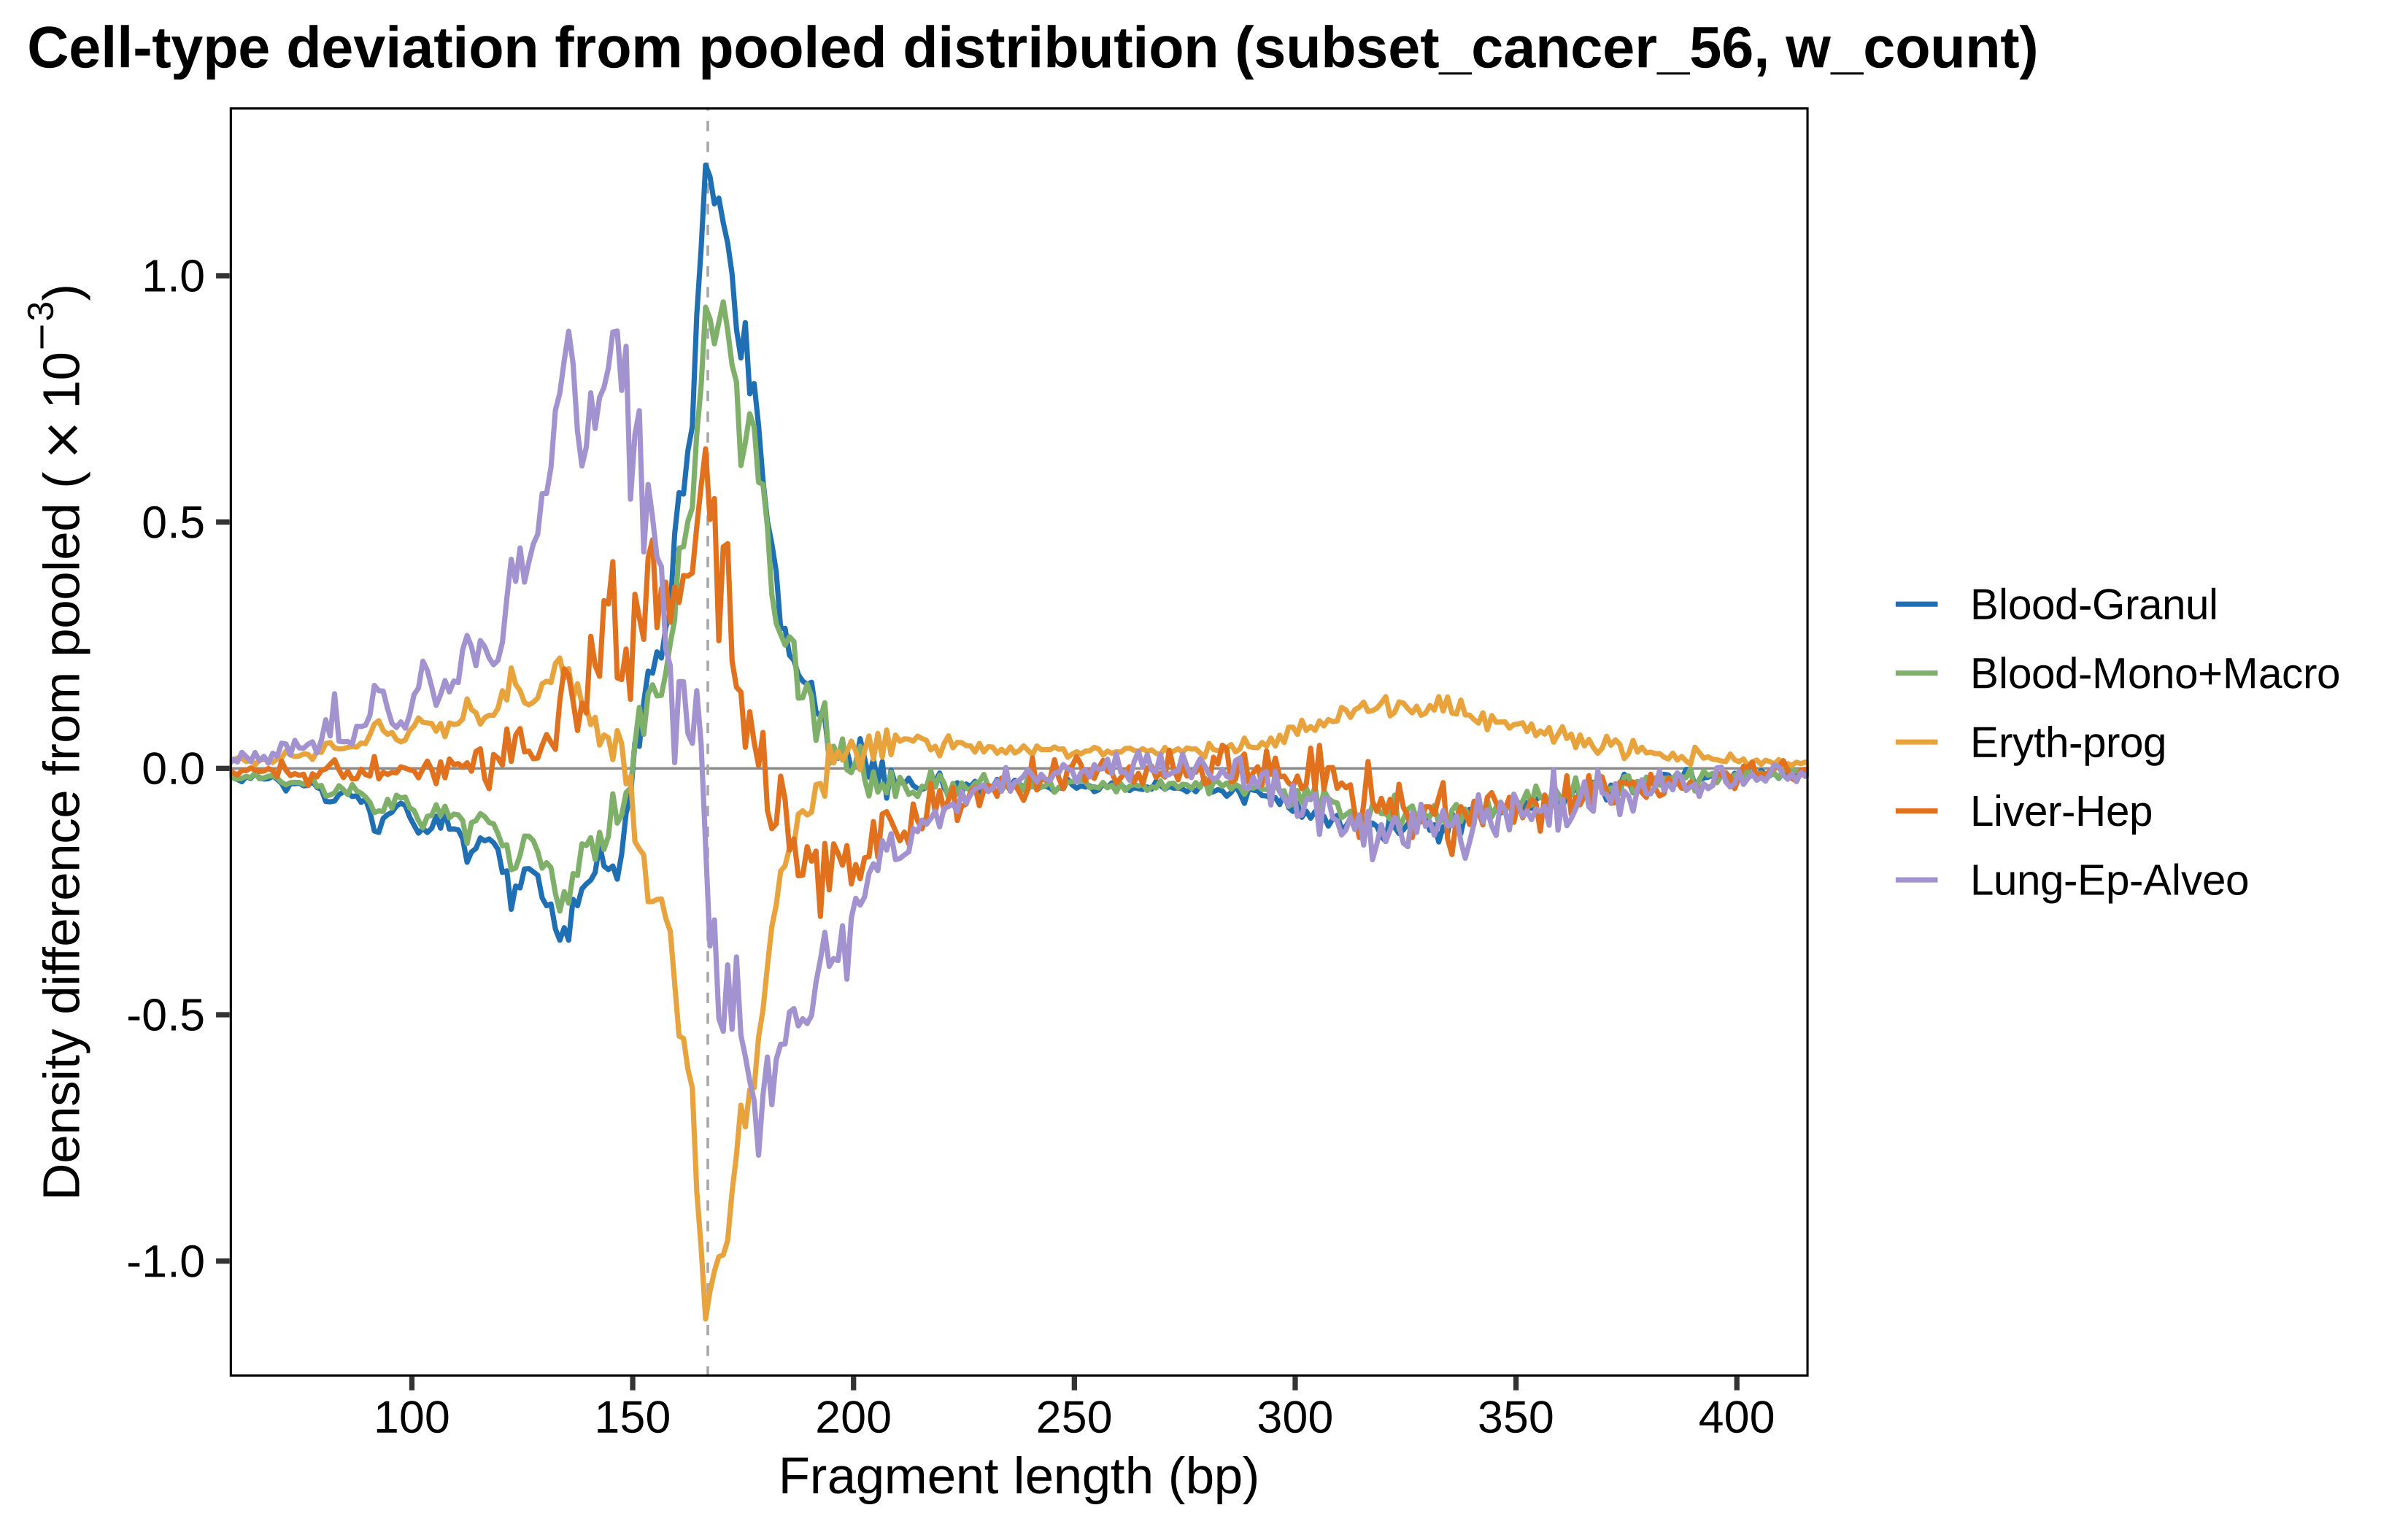

In [19]:
options(repr.plot.width = 11, repr.plot.height = 7, repr.plot.res = 300)
run_fld("subset_cancer_56", "w_count")

In [ ]:
# Done #